In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv(r"C:\Users\Dell\Documents\My ML Projects\Hybrid Recommendation System\data\movie.csv")
ratings = pd.read_csv(r"C:\Users\Dell\Documents\My ML Projects\Hybrid Recommendation System\data\rating.csv")
tags = pd.read_csv(r"C:\Users\Dell\Documents\My ML Projects\Hybrid Recommendation System\data\tag.csv")


In [3]:
print("Movies shape:",movies.shape)
movies.head()

Movies shape: (27278, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
print("Ratings shape:",ratings.shape)
ratings.head()


Ratings shape: (20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [5]:
print("Tags shape:",tags.shape)
tags.head()

Tags shape: (465564, 4)


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


“The dataset contained over 20 million ratings, which introduced computational and memory challenges. To handle this, I used sampling during development and optimized matrix operations to ensure scalability.”

In [6]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB


In [7]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  str    
dtypes: float64(1), int64(2), str(1)
memory usage: 610.4 MB


In [8]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 465564 entries, 0 to 465563
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   userId     465564 non-null  int64
 1   movieId    465564 non-null  int64
 2   tag        465548 non-null  str  
 3   timestamp  465564 non-null  str  
dtypes: int64(2), str(2)
memory usage: 14.2 MB


**Checking for missing values**


In [9]:
#movie data set null values
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [10]:
#ratings dataset null values
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [11]:
#tags data set null values
tags.isnull().sum()

userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

Checking no of unique users and movies 

In [12]:
ratings['userId'].nunique()

138493

In [13]:
ratings['movieId'].nunique()

26744

“Due to extreme sparsity (~99%), relying only on collaborative filtering is not effective. Therefore, a hybrid approach combining collaborative and content-based filtering is necessary.

In [42]:
print(ratings['rating'].describe())

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


📊 Ratings Distribution Analysis

Key Stats:

⭐ Mean: 3.52

📊 Median: 3.5

📈 75% of ratings ≤ 4

📉 Min: 0.5

📈 Max: 5

🧠 Important Insights

1️⃣ Ratings are skewed towards higher values
Most ratings are between 3 → 5
Very few low ratings

👉 Meaning:

Users usually rate movies they like, not dislike

2️⃣ Positive Bias in Data
Average is above neutral (3)
Median also high (3.5)

👉 Problem:

Model may assume everything is “good”

3️⃣ Weak Negative Signal ❗
Few low ratings → less information about dislikes

👉 Impact:

Harder for model to learn what NOT to recommend

4️⃣ Narrow Range (Low Variance)
Std ≈ 1.05 → ratings are somewhat concentrated

👉 Meaning:

Differences between movies are subtle

The rating distribution shows a positive bias, with most ratings between 3 and 5. This indicates that users tend to rate movies they like, leading to limited negative feedback. This affects model learning and reinforces the need for hybrid recommendation to improve diversity.

**Ratings Distribution**

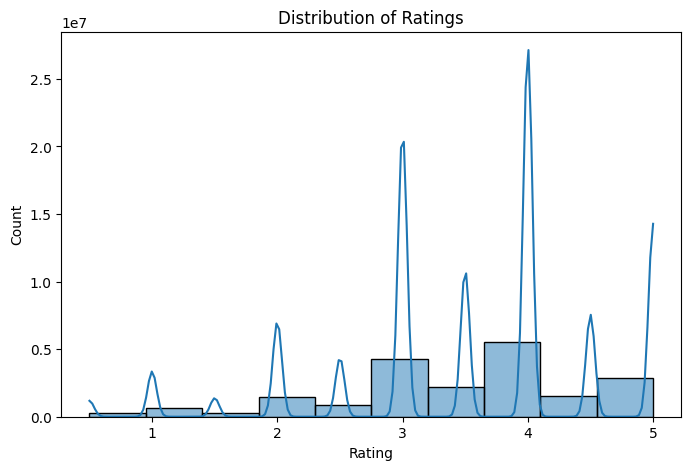

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

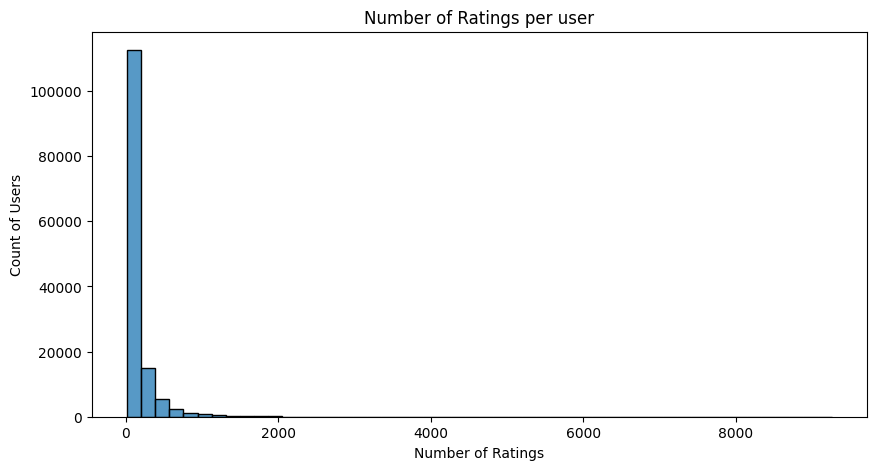

In [15]:
ratings_per_user = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.histplot(ratings_per_user,bins=50, kde=False)
plt.title("Number of Ratings per user")
plt.xlabel("Number of Ratings")
plt.ylabel("Count of Users")
plt.show()

**Movie genres Analysis**

In [16]:
movies = pd.read_csv(r"C:\Users\Dell\Documents\My ML Projects\Hybrid Recommendation System\data\movie.csv")



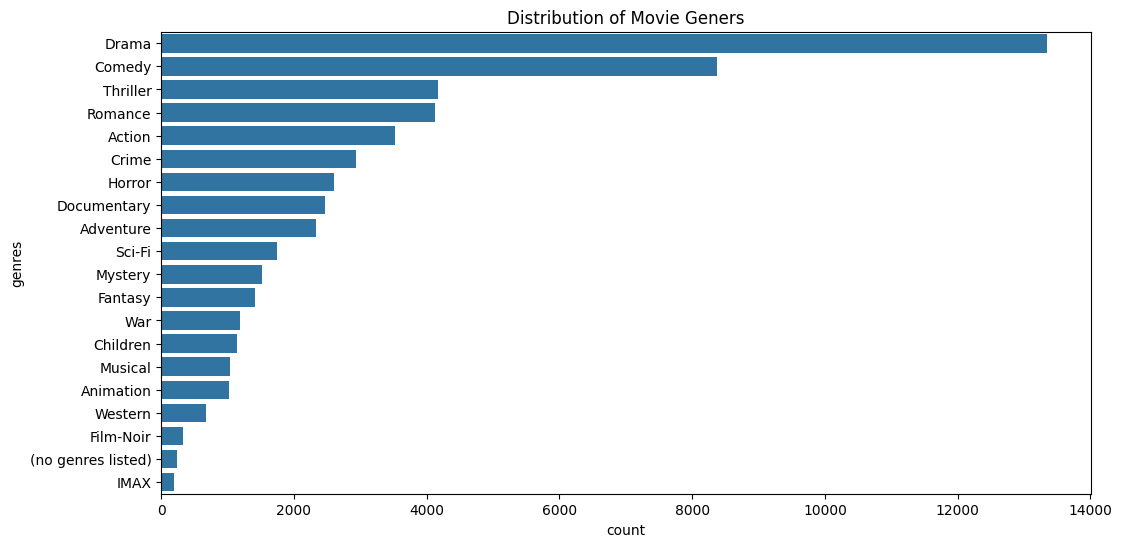

In [17]:
#split genres and count
movies['genres'] = movies['genres'].str.split('|')
all_genres = movies['genres'].explode()
plt.figure(figsize=(12,6))
sns.countplot(y=all_genres,order=all_genres.value_counts().index)
plt.title("Distribution of Movie Geners")
plt.show()


In [18]:
movies['genres'].head()

0    [Adventure, Animation, Children, Comedy, Fantasy]
1                       [Adventure, Children, Fantasy]
2                                    [Comedy, Romance]
3                             [Comedy, Drama, Romance]
4                                             [Comedy]
Name: genres, dtype: object

**Most Rated Movies**

In [19]:
#merge movies and ratings
movie_ratings = ratings.merge(movies,on = 'movieId')

#count ratings per movie
top_movies= movie_ratings.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

print(top_movies)


title
Pulp Fiction (1994)                          67310
Forrest Gump (1994)                          66172
Shawshank Redemption, The (1994)             63366
Silence of the Lambs, The (1991)             63299
Jurassic Park (1993)                         59715
Star Wars: Episode IV - A New Hope (1977)    54502
Braveheart (1995)                            53769
Terminator 2: Judgment Day (1991)            52244
Matrix, The (1999)                           51334
Schindler's List (1993)                      50054
Name: rating, dtype: int64


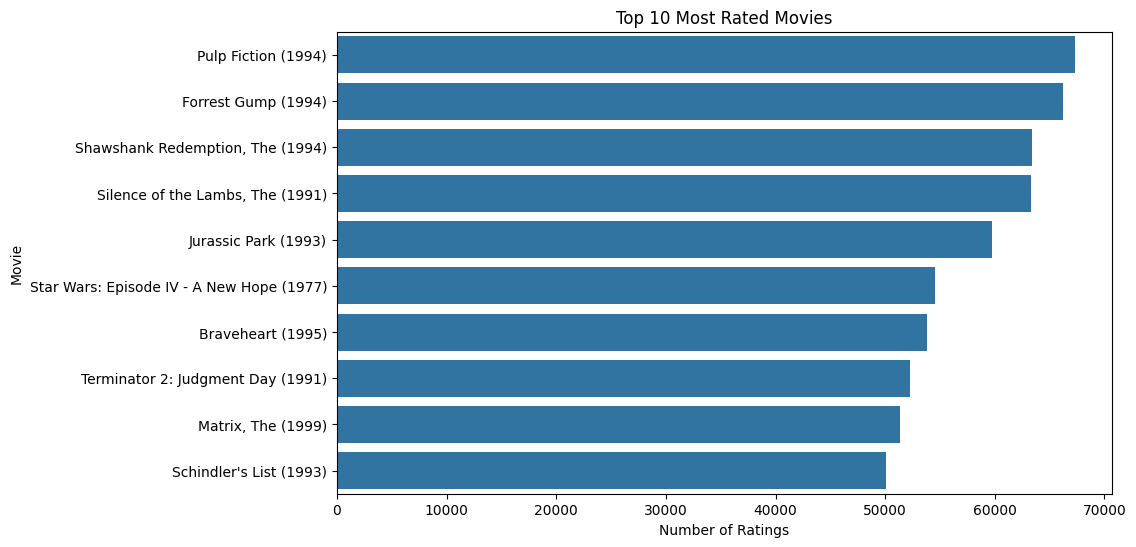

In [20]:
#plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_movies.values, y=top_movies.index)
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.show()

**Most Active Users**

userId
118205    9254
8405      7515
82418     5646
121535    5520
125794    5491
74142     5447
34576     5356
131904    5330
83090     5169
59477     4988
Name: count, dtype: int64


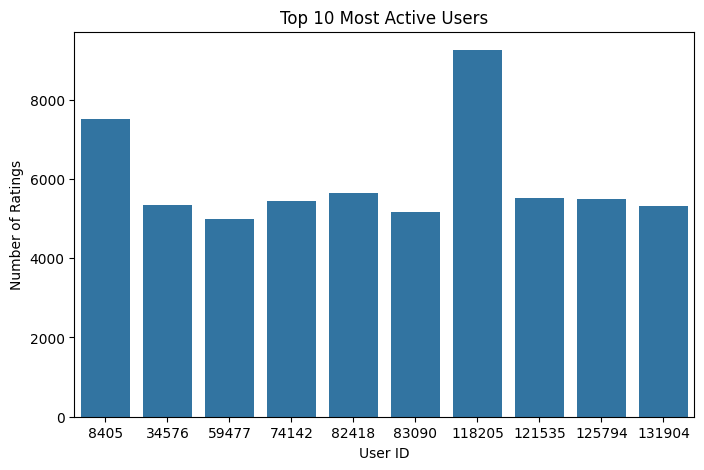

In [21]:
top_users=ratings['userId'].value_counts().head(10)

print(top_users)

plt.figure(figsize=(8,5))
sns.barplot(x=top_users.index,y=top_users.values)
plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.show()

**Average Rating per Movie(Quality insight)**



In [22]:
avg_ratings = movie_ratings.groupby('title')['rating'].mean().sort_values(ascending=False)
print(avg_ratings.head(20))

title
Tales That Witness Madness (1973)                                            5.0
Stargate SG-1 Children of the Gods - Final Cut (2009)                        5.0
Stealing a Nation (2004)                                                     5.0
Abendland (2011)                                                             5.0
Latin Music USA (2009)                                                       5.0
Pursuit of Unhappiness, The (Anleitung zum Unglücklichsein) (2012)           5.0
Parasites, Les (1999)                                                        5.0
This Thing With Sarah (2013)                                                 5.0
Inquire Within (2012)                                                        5.0
Island at War (2004)                                                         5.0
Iran Is Not the Problem (2008)                                               5.0
Donos de Portugal (2012)                                                     5.0
The Beautiful Story (1

**Popular vs Highly Rated(Important for Recommendation)**


In [23]:
movie_stats=movie_ratings.groupby('title').agg({
    'rating':['mean','count']
})

movie_stats.columns = ['avg_rating','num_ratings']

#Filter movies with enough ratings(avoid noise)
popular_movies = movie_stats[movie_stats['num_ratings']>50]

In [24]:
popular_movies.head(10)

,avg_rating,num_ratings
title,,
$9.99 (2008),3.009091,55
'Hellboy': The Seeds of Creation (2004),3.028736,87
'Round Midnight (1986),3.615385,182
'Salem's Lot (2004),3.111538,130
'Til There Was You (1997),2.847115,520
"'burbs, The (1989)",3.067391,3220
'night Mother (1986),3.449153,354
(500) Days of Summer (2009),3.804231,5767
*batteries not included (1987),3.245087,1730


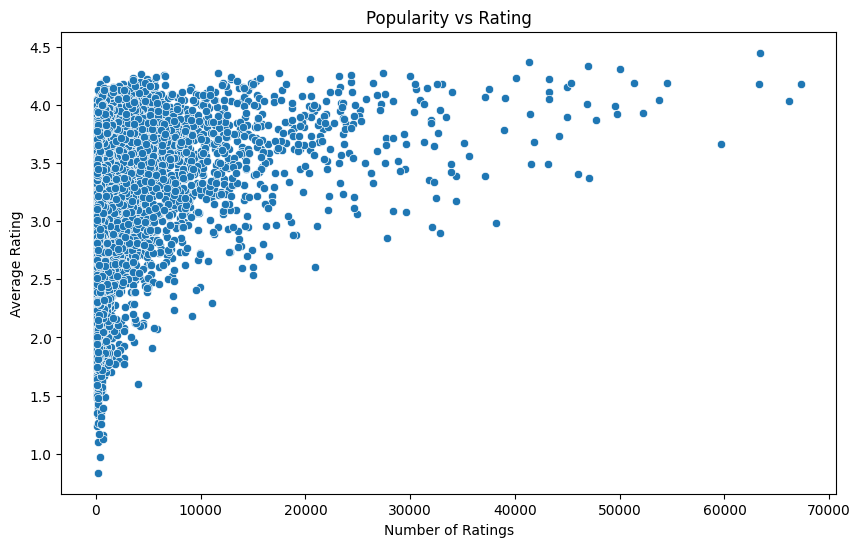

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=popular_movies,x='num_ratings',y='avg_rating')
plt.title("Popularity vs Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

**Ratings Over Time**

In [26]:
ratings_sample = ratings.sample(2000000,random_state=42)
ratings_sample['timestamp'] = pd.to_datetime(ratings_sample['timestamp'], unit='s')

ratings_sample['year'] = ratings_sample['timestamp'].dt.year


ratings_per_year = ratings_sample.groupby('year').size()

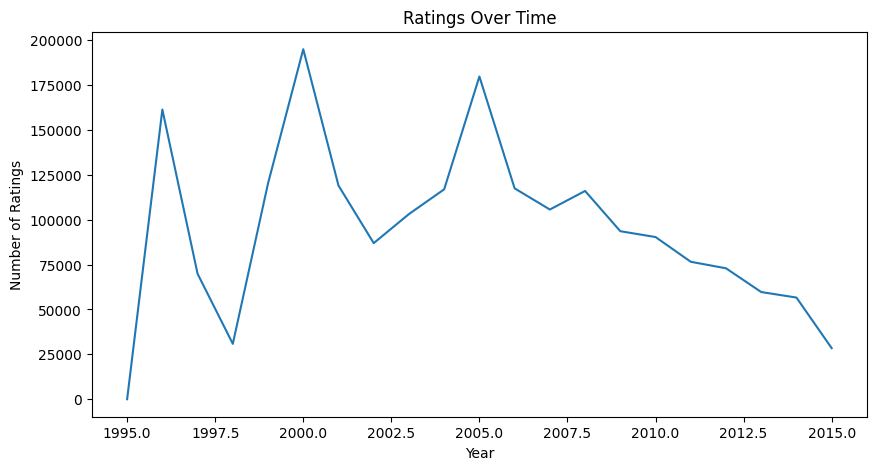

In [27]:
plt.figure(figsize=(10,5))
ratings_per_year.plot()
plt.title("Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

**Genre-Wise Average Ratings**

In [29]:
#Explode genres again
movies_expanded=movies.copy()
movies_expanded['genres'] = movies_expanded['genres'].str.split('|')
movies_expanded = movies_expanded.explode('genres')

#Merge with ratings
genre_ratings=ratings.merge(movies_expanded,on='movieId')

genre_avg = genre_ratings.groupby('genres')['rating'].mean().sort_values(ascending=False)

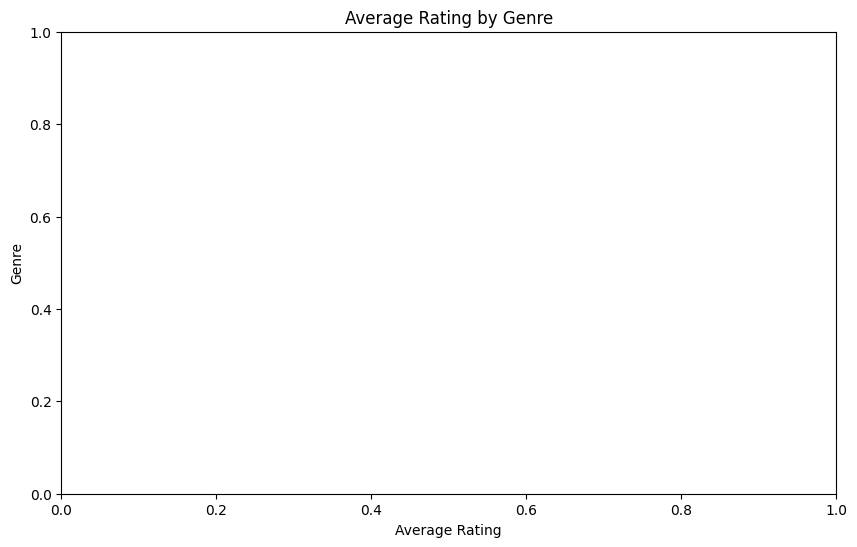

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=genre_avg.values, y=genre_avg.index)
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

**Data Sparsity**

In [31]:

num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()

actual_ratings = len(ratings)
possible_ratings = num_users*num_movies

sparsity = (1 - (actual_ratings/possible_ratings))*100

print(f"Sparsity of dataset: {sparsity:.2f}%")



Sparsity of dataset: 99.46%


**Correlation Between Movies**

In [40]:
#compute similarity on demand
sample_ratings = ratings.sample(20000, random_state=42)

user_movie_matrix = sample_ratings.pivot_table(
    index='userId', columns='movieId', values='rating'
)


In [41]:
user_movie_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,115945,116797,116841,116977,118700,119145,124647,128688,128695,130512
userId,,,,,,,,,,,,,,,,,,,,,
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Check Cold Start Problem**

In [37]:
#users with very few ratings
# Ratings per user
ratings_per_user = ratings_sample.groupby('userId')['rating'].count()

# Ratings per movie
ratings_per_movie = ratings_sample.groupby('movieId')['rating'].count()
cold_users = ratings_per_user[ratings_per_user<5]
print("Users with <5 ratings:",len(cold_users))

#movies with very few ratings

cold_movies = ratings_per_movie[ratings_per_movie<5]
print("Movies with <5 ratings:",len(cold_movies))

Users with <5 ratings: 45437
Movies with <5 ratings: 6873


“From EDA, I observed that a large number of users had fewer than 5 ratings and many movies had very few interactions, leading to a severe cold start problem. To address this, I implemented a hybrid recommendation system combining collaborative filtering with content-based methods.”